# Laboratorio 10 - Optimización con SciPy

**Nombre:**  Emilio Alejandro Illanes Loyola   
**RUT:**  21.017.984-4   
**Fecha:**  27/05/2026  


# Importación de librerías

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

# Carga del dataset

Asegúrate de subir el archivo `dataset_produccion_s13.csv` al mismo entorno del notebook antes de ejecutar.


In [38]:
df = pd.read_csv("dataset_produccion_s13.csv")

df.head()

,id_lote,producto,turno,unidades_producidas,costo_unitario,temperatura_horno,tiempo_ciclo_min,defectos,costo_total
0,L001,Abrazadera D,Tarde,114,1.95,204.4,37.8,8.0,222.30
1,L002,Válvula E,Tarde,306,2.83,230.8,56.8,11.0,865.98
2,L003,Tuerca C,Tarde,180,3.66,242.8,44.8,4.0,658.80
3,L004,Válvula E,Tarde,210,2.14,242.1,38.5,0.0,449.40
4,L005,Válvula E,Tarde,336,4.87,234.6,14.9,9.0,1636.32


# Información general del dataset

In [39]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id_lote              60 non-null     object 
 1   producto             60 non-null     object 
 2   turno                60 non-null     object 
 3   unidades_producidas  60 non-null     int64  
 4   costo_unitario       59 non-null     float64
 5   temperatura_horno    59 non-null     float64
 6   tiempo_ciclo_min     60 non-null     float64
 7   defectos             59 non-null     float64
 8   costo_total          60 non-null     float64
dtypes: float64(5), int64(1), object(3)
memory usage: 4.3+ KB


,unidades_producidas,costo_unitario,temperatura_horno,tiempo_ciclo_min,defectos,costo_total
count,60.000000,59.000000,59.000000,60.000000,59.000000,60.000000
mean,244.266667,2.664576,229.406780,35.813333,7.203390,656.710667
std,90.248408,1.297236,104.204605,15.335662,4.494363,407.032651
min,84.000000,0.570000,180.400000,-5.000000,0.000000,62.980000
25%,172.500000,1.590000,197.850000,24.600000,4.000000,338.775000
50%,250.500000,2.740000,219.800000,37.450000,7.000000,609.940000
75%,312.250000,3.580000,235.100000,48.825000,11.500000,894.045000
max,397.000000,4.940000,999.900000,59.500000,14.000000,1636.320000


In [40]:
df.isnull().sum()

,0
id_lote,0
producto,0
turno,0
unidades_producidas,0
costo_unitario,1
temperatura_horno,1
tiempo_ciclo_min,0
defectos,1
costo_total,0


In [41]:
media = df["temperatura_horno"].mean()
desviacion = df["temperatura_horno"].std()

outliers = df[
    (df["temperatura_horno"] < media - 3*desviacion) |
    (df["temperatura_horno"] > media + 3*desviacion)
]

print(outliers)

   id_lote    producto  turno  unidades_producidas  costo_unitario  \
33    L034  Tornillo A  Noche                  124            0.68   

    temperatura_horno  tiempo_ciclo_min  defectos  costo_total  
33              999.9              24.3       4.0        84.32  


# Reflexión sobre valores negativos

Un valor negativo en tiempo de ciclo mínimo no tiene sentido porque el tiempo es una duración real del proceso de producción, el tiempo que dura el proceso no puede ser menor a 0

In [42]:
temperatura = df["temperatura_horno"].dropna()

print("Media:", temperatura.mean())
print("Mediana:", temperatura.median())
print("Desviación estándar:", temperatura.std())
print("Mínimo:", temperatura.min())
print("Máximo:", temperatura.max())

Media: 229.40677966101694
Mediana: 219.8
Desviación estándar: 104.20460454517415
Mínimo: 180.4
Máximo: 999.9


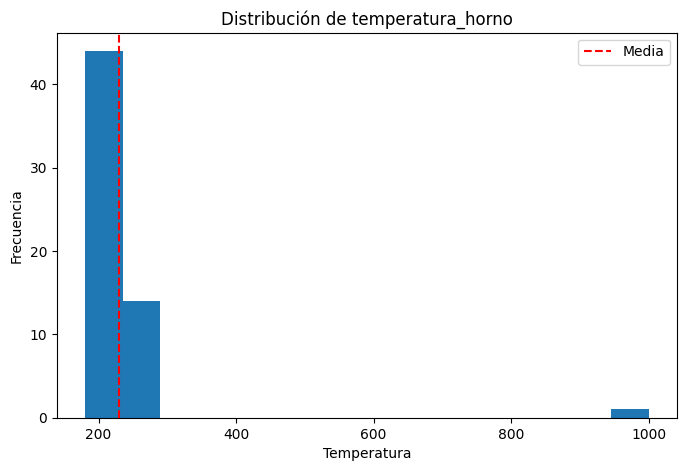

In [43]:
plt.figure(figsize=(8,5))

plt.hist(temperatura, bins=15)

plt.axvline(
    temperatura.mean(),
    linestyle='--',
    label='Media',
    color='red'
)

plt.title("Distribución de temperatura_horno")
plt.xlabel("Temperatura")
plt.ylabel("Frecuencia")

plt.legend()

plt.show()

# Interpretación

La temperatura se mantiene estable y casi siempre ronda el promedio. Esto demuestra que la producción funciona con normalidad, lo que nos facilita reducir costos y optimizar el proceso.


# Ejercicio 2 — Función de costo

In [44]:
def costo_produccion(temperatura):

    T_optima = 220
    costo_base = 1500

    return 0.05 * (temperatura - T_optima)**2 + costo_base

In [45]:
print(costo_produccion(220))

1500.0


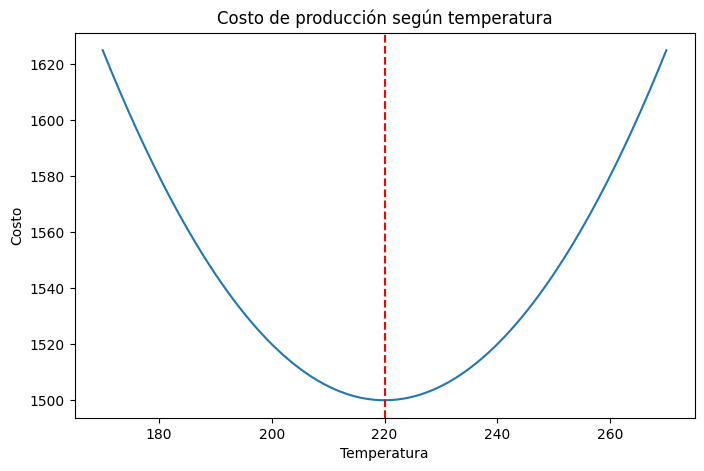

In [46]:
temperaturas = np.linspace(170, 270, 200)

costos = costo_produccion(temperaturas)

plt.figure(figsize=(8,5))

plt.plot(temperaturas, costos)
plt.axvline(220, color='red', linestyle='--', label='Temperatura óptima')
plt.title("Costo de producción según temperatura")
plt.xlabel("Temperatura")
plt.ylabel("Costo")

plt.show()

# Análisis

La función tiene un solo punto más bajo. Por eso, `minimize_scalar` sirve para encontrar la mejor temperatura.

# Optimización con método Brent

In [47]:
resultado_brent = minimize_scalar(
    costo_produccion,
    method='brent'
)

print("Temperatura óptima:", resultado_brent.x)
print("Costo mínimo:", resultado_brent.fun)
print("Convergencia:", resultado_brent.success)
print("Iteraciones:", resultado_brent.nit)

if resultado_brent.success:
    print("Optimización exitosa")

Temperatura óptima: 220.0000000000022
Costo mínimo: 1500.0
Convergencia: True
Iteraciones: 4
Optimización exitosa



La temperatura óptima encontrada es de aproximadamente 220 °C

# Optimización con método bounded

In [48]:
resultado_bounded = minimize_scalar(
    costo_produccion,
    bounds=(180, 250),
    method='bounded'
)

print("Temperatura óptima:", resultado_bounded.x)
print("Costo mínimo:", resultado_bounded.fun)
print("Convergencia:", resultado_bounded.success)
print("Iteraciones:", resultado_bounded.nit)

Temperatura óptima: 220.00000000000006
Costo mínimo: 1500.0
Convergencia: True
Iteraciones: 6


# Comparación entre métodos

Ambos métodos llegan prácticamente al mismo resultado. Sin embargo, el método `bounded` es más adecuado en entornos industriales. Esto se debe a que respeta los límites físicos y de seguridad del sistema.

In [49]:
comparacion = pd.DataFrame({
    'Metodo': ['brent', 'bounded'],
    'x_optimo': [resultado_brent.x, resultado_bounded.x],
    'costo_min': [resultado_brent.fun, resultado_bounded.fun],
    'iteraciones': [resultado_brent.nit, resultado_bounded.nit],
    'convergio': [resultado_brent.success, resultado_bounded.success]
})

print(comparacion.to_string(index=False))

 Metodo  x_optimo  costo_min  iteraciones  convergio
  brent     220.0     1500.0            4       True
bounded     220.0     1500.0            6       True


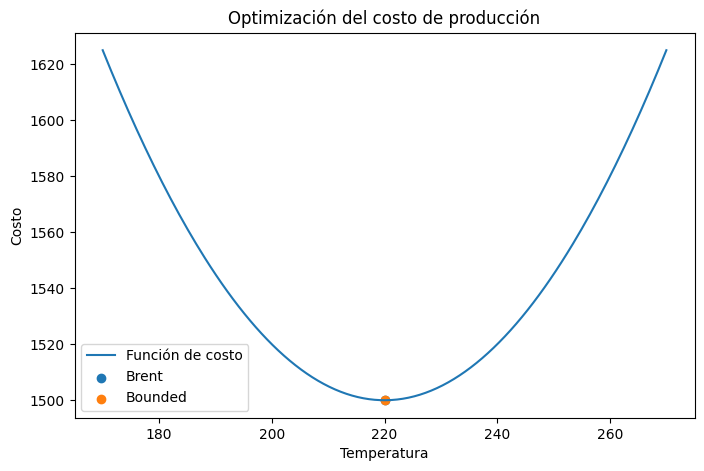

In [50]:
plt.figure(figsize=(8,5))

plt.plot(temperaturas, costos, label='Función de costo')

plt.scatter(
    resultado_brent.x,
    resultado_brent.fun,
    label='Brent'
)

plt.scatter(
    resultado_bounded.x,
    resultado_bounded.fun,
    label='Bounded'
)

plt.xlabel("Temperatura")
plt.ylabel("Costo")

plt.title("Optimización del costo de producción")

plt.legend()

plt.show()

# Reflexión Final

## 1. Ventaja de bounds

Usar límites reales nos ayuda a simular el comportamiento verdadero del horno. Así evitamos soluciones teóricas que en la práctica serían imposibles o peligrosas.

## 2. Funciones con múltiples mínimos locales

El problema con minimize_scalar es que se conforma con el primer mínimo que encuentra. Si hay varios, podría ignorar el mejor de todos, por lo que necesitaríamos una estrategia global para no quedarnos a medias.

## 3. Función de costo asimétrica

Si el efecto de la temperatura fuera asimétrico, se podría modificar la función de costo utilizando penalizaciones diferentes dependiendo de si la temperatura está por encima o por debajo del valor óptimo.
